ge: 8.012e+09 Hz 

ef: 7.682e+09 Hz

In [ ]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [ ]:
import sklearn
from sklearn.decomposition import PCA

In [ ]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [ ]:
header = "D:/K_sunada/result/CDK184/"
# twotone(redout: 10.26GHz)# twotone(redout: 10.26GHz)#"/2025-08-11/2025-08-11T105902_c11a4eed-cw_twotone"
three_peak = "/2025-08-11/2025-08-11T124239_3acb8327-cw_twotone" #<ge>drive: R.T.-40dB,  readout: R.T.: -20 dB, vna power: -20dB
ge_peak = "/2025-08-11/2025-08-11T123819_9f777899-cw_twotone" #drive: R.T.-50dB,  readout: R.T.: -20 dB, vna power: -20dB
ef_peak = "/2025-08-11/2025-08-11T124047_f7ff113c-cw_twotone" #<ef>drive: R.T.-40dB,  readout: R.T.: -20 dB, vna power: -20dB

three peaks

In [ ]:
ddtwotone = datadict_from_hdf5(header + three_peak +"/data")
x1 = np.unique(ddtwotone['power']['values'])
y1 = np.unique(ddtwotone['frequency']['values'])
z1 = np.angle(ddtwotone['s11']['values'])
z1.shape

(11, 901)

C:\Users\qipe\AppData\Local\Temp\ipykernel_8480\2900181966.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


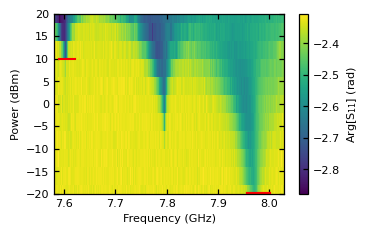

In [ ]:
cm = plt.cm.get_cmap('viridis')
fig= plt.figure(figsize=(3.2, 2.))

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_ylabel("Power (dBm)")
ax.set_xlabel("Frequency (GHz)")
# ax.set_xlim(-10, 20)
ax.set_ylim(-20, 20)

maingraph = ax.pcolormesh(y1*1e-9,x1, z1.reshape(11, 901), vmin=min(np.unique(z1)), vmax=max(np.unique(z1)), cmap=cm, shading='auto')
plt.colorbar(maingraph, label="Arg[S$_{11}$] (rad)")
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
ax.plot([7.96, 8], [-20, -20], c="red", lw=3)
ax.plot([7.59, 7.62], [10, 10], c="red", lw=1.5)
# plt.savefig('three_peaks.png', bbox_inches='tight')
plt.show()

ge, ef peak

In [ ]:
ddge = datadict_from_hdf5(header + ge_peak +"/data")
ddef = datadict_from_hdf5(header + ef_peak +"/data")

In [ ]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## ge

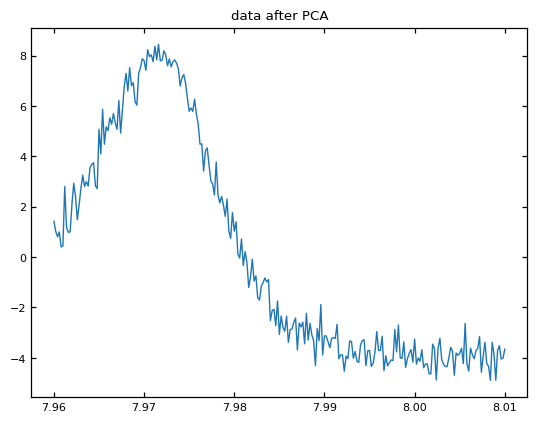

In [ ]:
S11ge = ddge['s11']['values']
ge_phase = np.angle(S11ge)
freqge = ddge['frequency']['values']
idx=10
I = (S11ge.real)[idx]
Q = (S11ge.imag)[idx]

PCAge = PCA_transform(I, Q)
y2 = PCAge[0]*1e4
x2 = freqge[0]*1e-9

plt.plot(x2, y2)
plt.title("data after PCA")
plt.show()

In [ ]:
par_ini = {'amp': 10,'const':0,'center':7.97,'k':0.01}
par_min = {'amp': -np.inf,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}

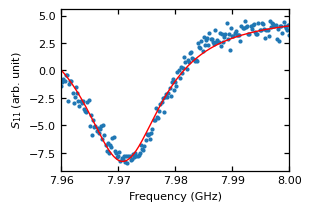

In [ ]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result2 = model.fit(data = y2, params = params, freq = x2)
result2
fig, ax = plt.subplots(figsize=(3,2),constrained_layout=True)

# result.plot_fit(ax = ax)
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(7.96, 8)
plt.plot(x2, -y2, 'o' ,c="tab:blue")
plt.plot(x2, -result2.best_fit, c="red", lw=1.0)
plt.title("")
# plt.legend("")
plt.xlabel("Frequency (GHz)")
plt.ylabel("$S_{11}$ (arb. unit)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

## ef   

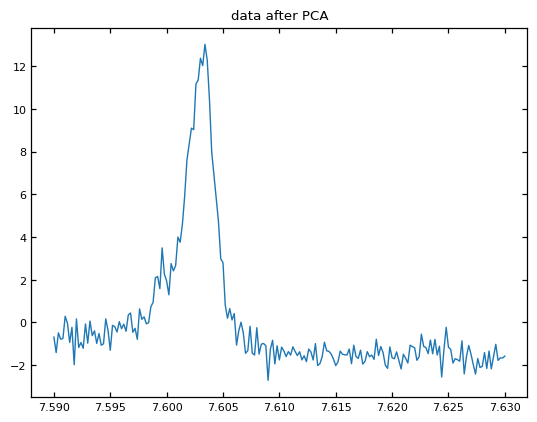

In [ ]:
S11ef = ddef['s11']['values']
ef_phase = np.angle(S11ef)
freqef = ddef['frequency']['values']
idx=10
I = (S11ef.real)[idx]
Q = (S11ef.imag)[idx]

PCAef = PCA_transform(I, Q)
y3 = PCAef[0]*1e4
x3 = freqef[0]*1e-9

plt.plot(x3, y3)
plt.title("data after PCA")
plt.show()

In [ ]:
par_ini = {'amp': 10,'const':0,'center':7.603,'k':0.01}
par_min = {'amp': -np.inf,'const':-np.inf,'center':0,'k':0}
par_max = {'amp': np.inf,'const':np.inf,'center':np.inf,'k':np.inf}
par_vary = {'amp': True,'const':True,'center':True,'k':True}

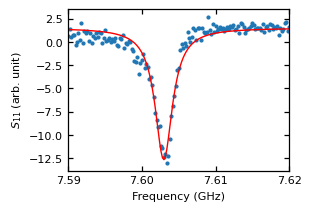

In [ ]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result3 = model.fit(data = y3, params = params, freq = x3)
result3
fig, ax = plt.subplots(figsize=(3,2),constrained_layout=True)

# result.plot_fit(ax = ax)
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

plt.xlim(7.59, 7.62)
plt.plot(x3, -y3, 'o' ,c="tab:blue")
plt.plot(x3, -result3.best_fit, c="red", lw=1.0)
# plt.plot(x, result.init_fit)
plt.title("")
# plt.legend("")
plt.xlabel("Frequency (GHz)")
plt.ylabel("$S_{11}$ (arb. unit)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_8480\2163683483.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


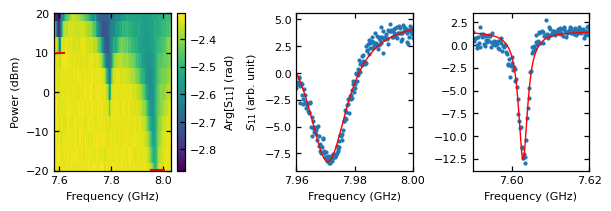

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(6, 2), constrained_layout=True)  # 横並び3つ

# 共通rcParams
plt.rcParams.update({
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'font.size': 8,
    'axes.linewidth': 0.9,
    'xtick.top': True,
    'xtick.bottom': True,
    'ytick.left': True,
    'ytick.right': True,
    'lines.linewidth': 1,
    'lines.markersize': 2
})

# -------------------------------
# 1枚目: colormap
ax = axes[0]
cm = plt.cm.get_cmap('viridis')
maingraph = ax.pcolormesh(y1*1e-9, x1, z1.reshape(11, 901), 
                          vmin=min(np.unique(z1)), vmax=max(np.unique(z1)),
                          cmap=cm, shading='auto')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power (dBm)")
ax.set_ylim(-20, 20)
# 赤線
ax.plot([7.96, 8], [-20, -20], c="red", lw=3)
ax.plot([7.59, 7.62], [10, 10], c="red", lw=1.5)
plt.colorbar(maingraph, ax=ax, label="Arg[S$_{11}$] (rad)")

# -------------------------------
# 2枚目: Lorentzian fit 1
ax = axes[2]
ax.plot(x3, -y3, 'o', c="tab:blue")
ax.plot(x3, -result3.best_fit, c="red", lw=1.0)
ax.set_xlim(7.59, 7.62)
ax.set_xlabel("Frequency (GHz)")
# ax.set_ylabel("$S_{11}$ (arb. unit)")

# -------------------------------
# 3枚目: Lorentzian fit 2
ax = axes[1]
ax.plot(x2, -y2, 'o', c="tab:blue")
ax.plot(x2, -result2.best_fit, c="red", lw=1.0)
ax.set_xlim(7.96, 8)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("$S_{11}$ (arb. unit)")

# -------------------------------
# 表示
plt.savefig("mas_figs/two-tone_rx.pdf", bbox_inches="tight")
plt.show()
